# Análise da amostra — PEDE 2024

Análise exploratória do arquivo Excel **BASE DE DADOS PEDE 2024**, considerando as colunas: `ipv`, `ips`, `iaa`, `ieg`, `nº_av`, `ida`, `Defasagem`.

In [1]:
import pandas as pd

# Usa regras do projeto: src.preprocessing.preparar_dados (carrega Excel e seleciona colunas)
from src.preprocessing import preparar_dados

# Carregar amostra conforme definido em src/utils.py e src/preprocessing.py
df_full = preparar_dados()
# Para análise exploratória, manter referência ao dataset "completo" (já filtrado por colunas de interesse)
df = df_full.copy()
print(f"Dimensões do dataset (colunas de interesse): {df.shape[0]} linhas, {df.shape[1]} colunas")
print(f"\nColunas utilizadas na análise:\n{list(df.columns)}")

Dimensões do dataset (colunas de interesse): 3030 linhas, 7 colunas

Colunas utilizadas na análise:
['IPV', 'IPS', 'IAA', 'IEG', 'Nº Av', 'IDA', 'Defasagem']


In [2]:
# Seleção de colunas feita por src.preprocessing.preparar_dados (regras em src/utils.py)
print(f"Amostra ({len(df)} linhas):")
df.head(10)

Amostra (3030 linhas):


,IPV,IPS,IAA,IEG,Nº Av,IDA,Defasagem
0,7.278,5.6,8.3,4.1,4.0,4.0,0
1,6.778,6.3,8.8,5.2,4.0,6.8,0
2,7.556,5.6,0.0,7.9,4.0,5.6,0
3,5.278,5.6,8.8,4.5,4.0,5.0,0
4,7.389,5.6,7.9,8.6,4.0,5.2,0
5,7.222,7.5,7.9,4.5,4.0,3.3,0
6,7.667,7.5,0.0,8.4,4.0,7.6,0
7,6.278,6.3,7.1,4.6,4.0,1.6,0
8,9.500,7.5,8.8,9.5,4.0,6.7,0
9,7.056,5.0,8.3,5.2,4.0,4.1,0


## 1. Resumo e tipos

Dimensões, tipos das colunas e valores faltantes.

In [3]:
print("Dimensões:", df.shape)
print("\nTipos:")
print(df.dtypes)
print("\nValores faltantes por coluna:")
print(df.isna().sum())
print("\nPercentual de faltantes:")
print((df.isna().sum() / len(df) * 100).round(2).astype(str) + "%")

Dimensões: (3030, 7)

Tipos:
IPV          float64
IPS          float64
IAA          float64
IEG          float64
Nº Av        float64
IDA          float64
Defasagem      int64
dtype: object

Valores faltantes por coluna:
IPV          178
IPS          171
IAA          165
IEG           76
Nº Av         76
IDA          178
Defasagem      0
dtype: int64

Percentual de faltantes:
IPV          5.87%
IPS          5.64%
IAA          5.45%
IEG          2.51%
Nº Av        2.51%
IDA          5.87%
Defasagem     0.0%
dtype: object


## 2. Estatísticas descritivas

Média, desvio padrão, mínimo, quartis e máximo para as colunas numéricas.

In [4]:
df.describe()

,IPV,IPS,IAA,IEG,Nº Av,IDA,Defasagem
count,2852.000000,2859.000000,2865.000000,2954.000000,2954.000000,2852.000000,3030.000000
mean,7.545476,6.287129,7.918225,7.945696,3.031821,6.375964,0.358416
std,1.084347,1.792491,2.626209,2.152281,1.063670,1.956637,0.479614
min,2.500000,2.500000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.984000,5.020000,7.900000,7.300000,2.000000,5.100000,0.000000
50%,7.583000,7.500000,8.751000,8.600000,3.000000,6.666667,0.000000
75%,8.255000,7.510000,9.500000,9.400000,4.000000,7.833333,1.000000
max,10.010000,10.000000,10.002000,10.000000,6.000000,10.000000,1.000000


## 3. Correlação entre as variáveis

Matriz de correlação (Pearson) das colunas numéricas.

In [5]:
# Apenas colunas numéricas para correlação
df_numeric = df.select_dtypes(include=["number"])
if df_numeric.shape[1] > 0:
    corr = df_numeric.corr()
    display(corr)
else:
    print("Não há colunas numéricas para calcular correlação.")

,IPV,IPS,IAA,IEG,Nº Av,IDA,Defasagem
IPV,1.000000,-0.048750,0.062728,0.558200,-0.128613,0.557072,0.001500
IPS,-0.048750,1.000000,0.157373,-0.046264,-0.066423,0.022485,-0.145260
IAA,0.062728,0.157373,1.000000,0.133078,-0.116039,0.115241,-0.082521
IEG,0.558200,-0.046264,0.133078,1.000000,0.296089,0.539057,0.110739
Nº Av,-0.128613,-0.066423,-0.116039,0.296089,1.000000,-0.203353,0.072982
IDA,0.557072,0.022485,0.115241,0.539057,-0.203353,1.000000,-0.009123
Defasagem,0.001500,-0.145260,-0.082521,0.110739,0.072982,-0.009123,1.000000


## 4. Visualização da correlação (heatmap)

Heatmap da matriz de correlação para facilitar a leitura.

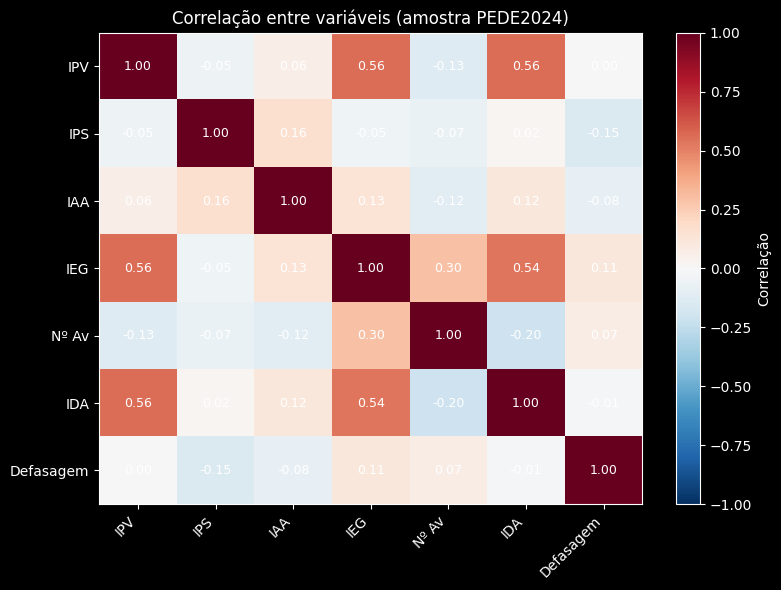

In [6]:
import matplotlib.pyplot as plt

if df_numeric.shape[1] > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    corr = df_numeric.corr()
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.columns)
    for i in range(len(corr)):
        for j in range(len(corr)):
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, label="Correlação")
    plt.title("Correlação entre variáveis (amostra PEDE2024)")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna numérica para heatmap.")

## 5. Valores faltantes por coluna

Percentual de missing por variável.

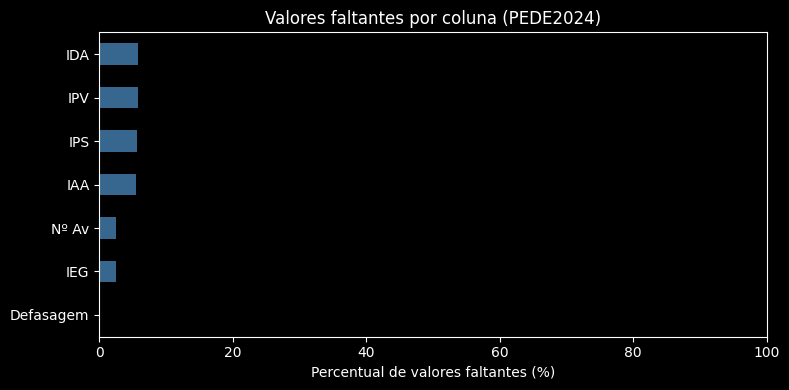

In [7]:
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
ax.set_xlabel("Percentual de valores faltantes (%)")
ax.set_title("Valores faltantes por coluna (PEDE2024)")
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## 6. Distribuição das variáveis numéricas

Histogramas para visualizar a distribuição de cada indicador.

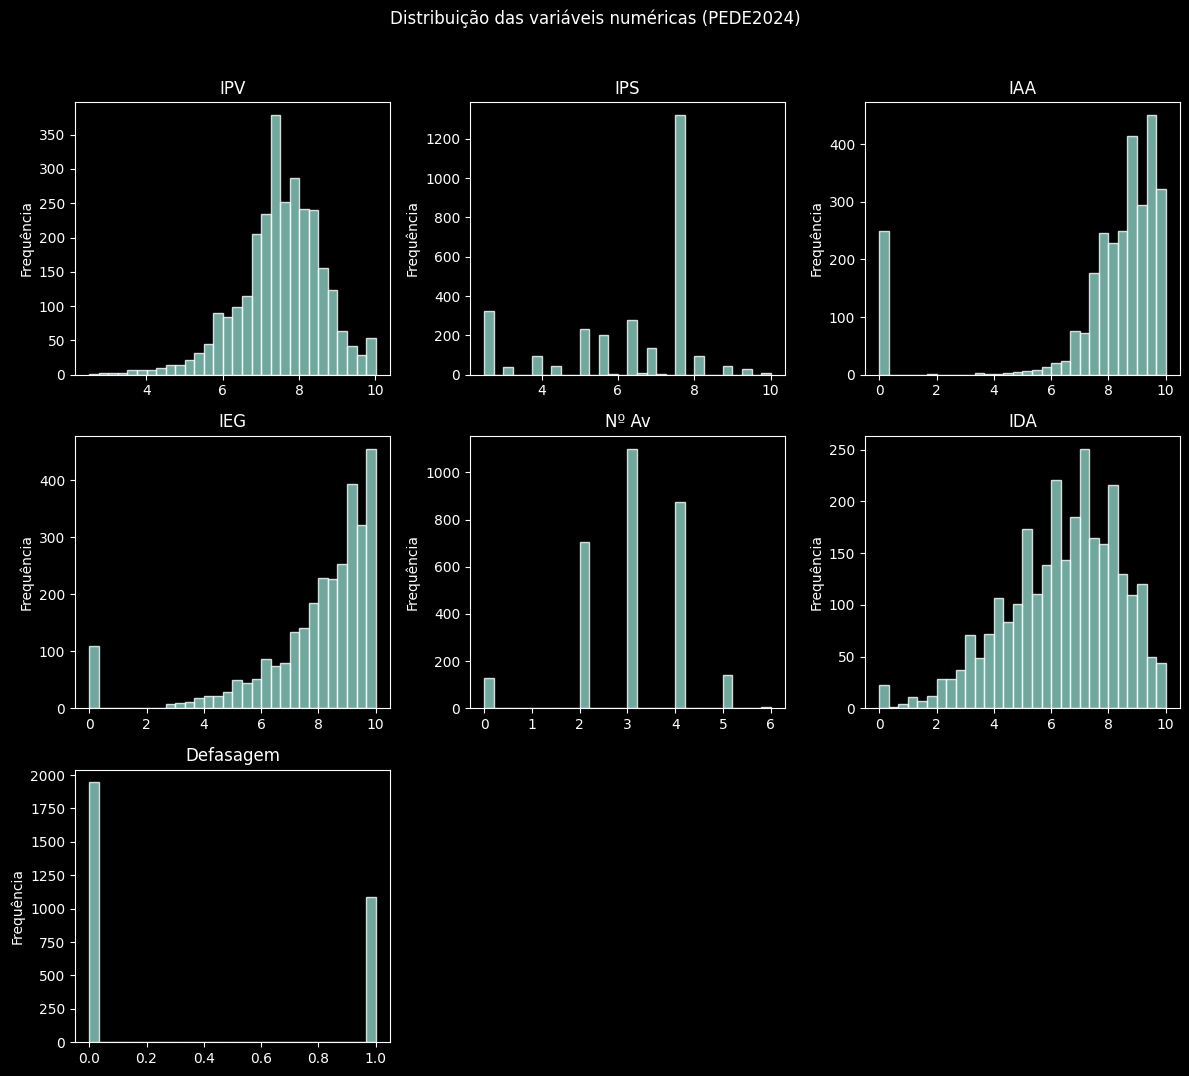

In [8]:
if df_numeric.shape[1] > 0:
    n_cols = df_numeric.shape[1]
    n_rows = (n_cols + 2) // 3  # até 3 colunas por linha
    fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3.5 * n_rows))
    axes = axes.flatten()
    for i, col in enumerate(df_numeric.columns):
        axes[i].hist(df_numeric[col].dropna(), bins=30, edgecolor="white", alpha=0.8)
        axes[i].set_title(col)
        axes[i].set_ylabel("Frequência")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Distribuição das variáveis numéricas (PEDE2024)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna numérica para histogramas.")

## 7. Box plots (dispersão e outliers)

Box plots para comparar escalas e identificar valores atípicos.

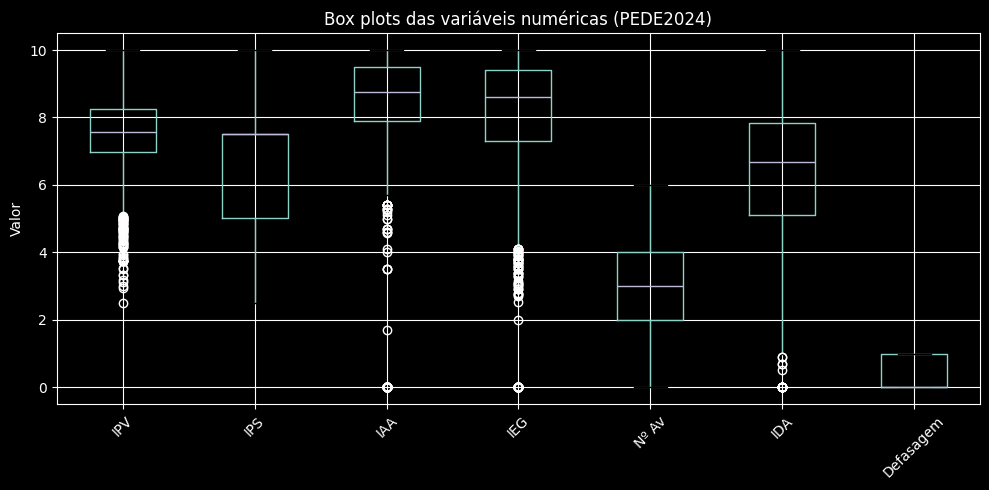

In [9]:
if df_numeric.shape[1] > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    df_numeric.boxplot(ax=ax, rot=45)
    ax.set_title("Box plots das variáveis numéricas (PEDE2024)")
    ax.set_ylabel("Valor")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma coluna numérica para box plots.")

## 8. Gráficos de dispersão (relações entre variáveis)

Dispersão entre pares de variáveis relevantes para explorar associações.

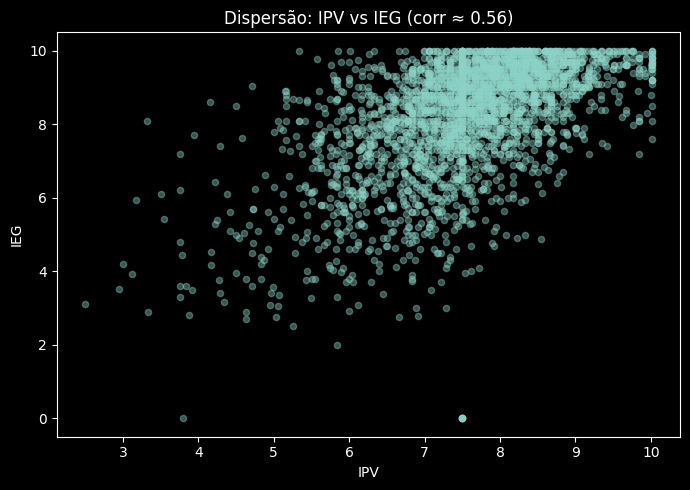

In [10]:
# Escolher duas variáveis para dispersão (ajuste os nomes se necessário)
cols = list(df_numeric.columns)
if len(cols) >= 2:
    # Par com maior correlação absoluta (excluindo diagonal)
    corr = df_numeric.corr()
    max_corr = 0
    par = (cols[0], cols[1])
    for i in range(len(cols)):
        for j in range(len(cols)):
            if i != j and abs(corr.iloc[i, j]) > max_corr:
                max_corr = abs(corr.iloc[i, j])
                par = (cols[i], cols[j])
    x_col, y_col = par
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(df_numeric[x_col], df_numeric[y_col], alpha=0.4, s=20)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"Dispersão: {x_col} vs {y_col} (corr ≈ {corr.loc[x_col, y_col]:.2f})")
    plt.tight_layout()
    plt.show()
else:
    print("São necessárias pelo menos 2 colunas numéricas para dispersão.")

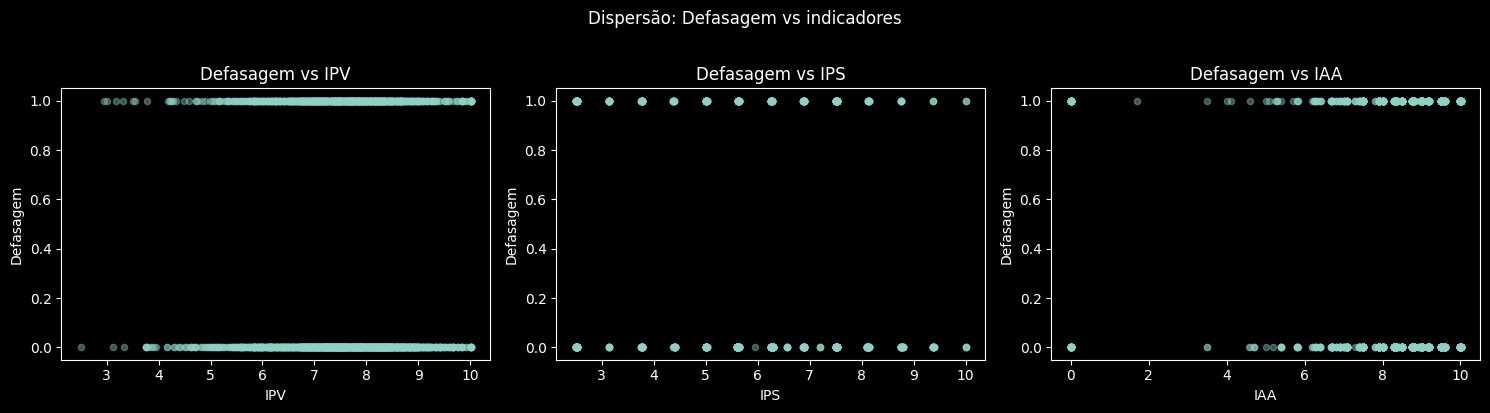

In [11]:
# Dispersão: Defasagem vs um indicador (se 'Defasagem' existir)
def_col = [c for c in df_numeric.columns if "defasagem" in str(c).lower() or "defas" in str(c).lower()]
if def_col and len(cols) >= 2:
    def_col = def_col[0]
    outras = [c for c in cols if c != def_col]
    n_plot = min(3, len(outras))
    fig, axes = plt.subplots(1, n_plot, figsize=(5 * n_plot, 4))
    if n_plot == 1:
        axes = [axes]
    for idx, col in enumerate(outras[:n_plot]):
        axes[idx].scatter(df_numeric[col], df_numeric[def_col], alpha=0.4, s=20)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(def_col)
        axes[idx].set_title(f"{def_col} vs {col}")
    plt.suptitle(f"Dispersão: {def_col} vs indicadores", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Coluna 'Defasagem' não encontrada ou insuficientes variáveis para múltiplos gráficos.")